In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score,
    roc_curve, ConfusionMatrixDisplay
)
from sklearn.inspection import permutation_importance

## 1) Chargement et nettoyage des données

In [2]:
df = pd.read_csv('./dataset/heart.csv')

df = pd.read_csv('/home/herilanja/Downloads/_DATA/heart.csv')

print("=" * 55)
print("APERÇU DU DATASET")
print("=" * 55)
print(f"  Dimensions      : {df.shape[0]} lignes × {df.shape[1]} colonnes")
print(f"  Variables       : {list(df.columns)}")
df.head(8)

APERÇU DU DATASET
  Dimensions      : 303 lignes × 14 colonnes
  Variables       : ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1
5,57,1,0,140,192,0,1,148,0,0.4,1,0,1,1
6,56,0,1,140,294,0,0,153,0,1.3,1,0,2,1
7,44,1,1,120,263,0,1,173,0,0.0,2,0,3,1


In [3]:
# Informations générales
print("=== Types et valeurs non-nulles ===")
df.info()

=== Types et valeurs non-nulles ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [5]:
print("=== Statistiques descriptives ===")
df.describe().round(2).transpose()


=== Statistiques descriptives ===


,count,mean,std,min,25%,50%,75%,max
age,303.0,54.37,9.08,29.0,47.5,55.0,61.0,77.0
sex,303.0,0.68,0.47,0.0,0.0,1.0,1.0,1.0
cp,303.0,0.97,1.03,0.0,0.0,1.0,2.0,3.0
trestbps,303.0,131.62,17.54,94.0,120.0,130.0,140.0,200.0
chol,303.0,246.26,51.83,126.0,211.0,240.0,274.5,564.0
fbs,303.0,0.15,0.36,0.0,0.0,0.0,0.0,1.0
restecg,303.0,0.53,0.53,0.0,0.0,1.0,1.0,2.0
thalach,303.0,149.65,22.91,71.0,133.5,153.0,166.0,202.0
exang,303.0,0.33,0.47,0.0,0.0,0.0,1.0,1.0
oldpeak,303.0,1.04,1.16,0.0,0.0,0.8,1.6,6.2


In [6]:
# ─── Nettoyage ────────────────────────────────────
print("=" * 55)
print("RAPPORT DE NETTOYAGE")
print("=" * 55)

# 1. Valeurs manquantes
na_count = df.isnull().sum()
print(f"\n1. Valeurs manquantes : {na_count.sum()} au total")
if na_count.sum() > 0:
    print(na_count[na_count > 0])

# 2. Doublons
dup = df.duplicated().sum()
print(f"\n2. Doublons : {dup}")
if dup > 0:
    df = df.drop_duplicates()
    print(f"   → {dup} ligne(s) supprimée(s). Nouveau shape : {df.shape}")

# 3. Valeurs aberrantes — cholestérol à 0
zero_chol = (df['chol'] == 0).sum()
print(f"\n3. Cholestérol = 0 : {zero_chol} cas")
if zero_chol > 0:
    df.loc[df['chol'] == 0, 'chol'] = df['chol'].median()
    print(f"   → Remplacés par la médiane : {df['chol'].median():.1f}")

# 4. Valeurs aberrantes — trestbps à 0
zero_bp = (df['trestbps'] == 0).sum()
print(f"\n4. Pression artérielle = 0 : {zero_bp} cas")
if zero_bp > 0:
    df.loc[df['trestbps'] == 0, 'trestbps'] = df['trestbps'].median()

# 5. Distribution de la cible
print(f"\n5. Distribution de la cible :")
vc = df['target'].value_counts()
for cls, cnt in vc.items():
    label = "Maladie cardiaque" if cls == 1 else "Sain"
    print(f"   Classe {cls} ({label}) : {cnt} ({cnt/len(df)*100:.1f}%)")

print(f"\nDataset propre : {df.shape[0]} lignes × {df.shape[1]} colonnes")


RAPPORT DE NETTOYAGE

1. Valeurs manquantes : 0 au total

2. Doublons : 1
   → 1 ligne(s) supprimée(s). Nouveau shape : (302, 14)

3. Cholestérol = 0 : 0 cas

4. Pression artérielle = 0 : 0 cas

5. Distribution de la cible :
   Classe 1 (Maladie cardiaque) : 164 (54.3%)
   Classe 0 (Sain) : 138 (45.7%)

Dataset propre : 302 lignes × 14 colonnes


## 2) Analyse exploratoire

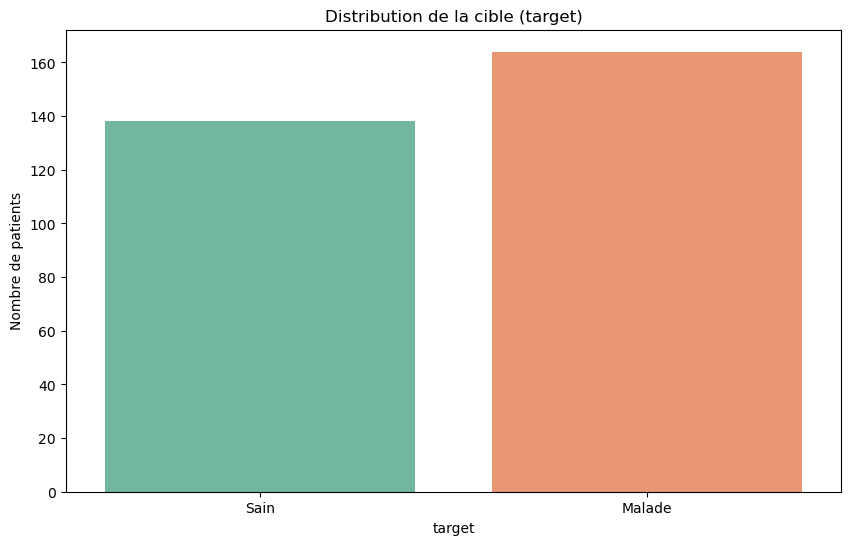

In [34]:
# ─── Visualisations ───────────────────────────────
plt.figure(figsize=(10, 6))
sns.countplot(x='target', data=df, palette='Set2')
plt.title('Distribution de la cible (target)')
plt.xticks([0, 1], ['Sain', 'Malade'])
plt.ylabel('Nombre de patients')
plt.savefig('./images/EDA/target_distribution.png', dpi=300, bbox_inches='tight')
plt.show()


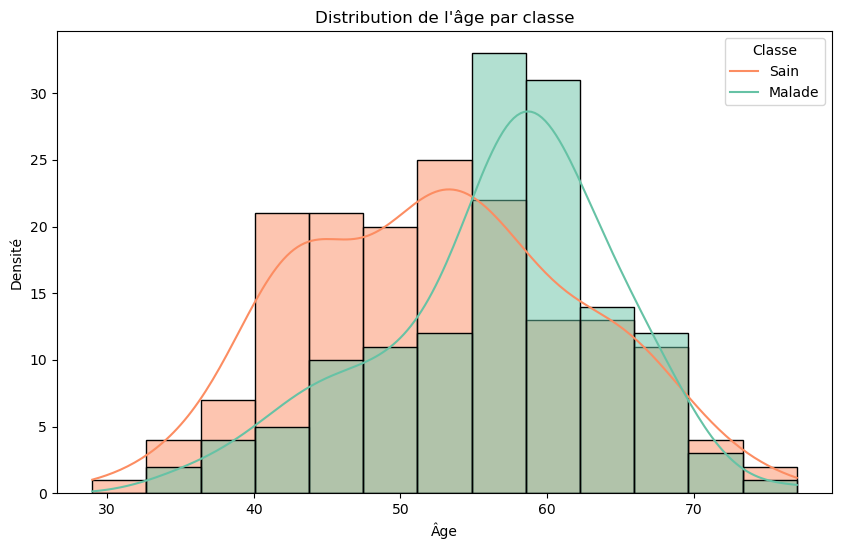

In [35]:
# ── Distribution âge par classe ──
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='age', hue='target', kde=True, palette='Set2')
plt.title('Distribution de l\'âge par classe')
plt.xlabel('Âge')
plt.ylabel('Densité')
plt.legend(title='Classe', labels=['Sain', 'Malade'])
plt.savefig('./images/EDA/age_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

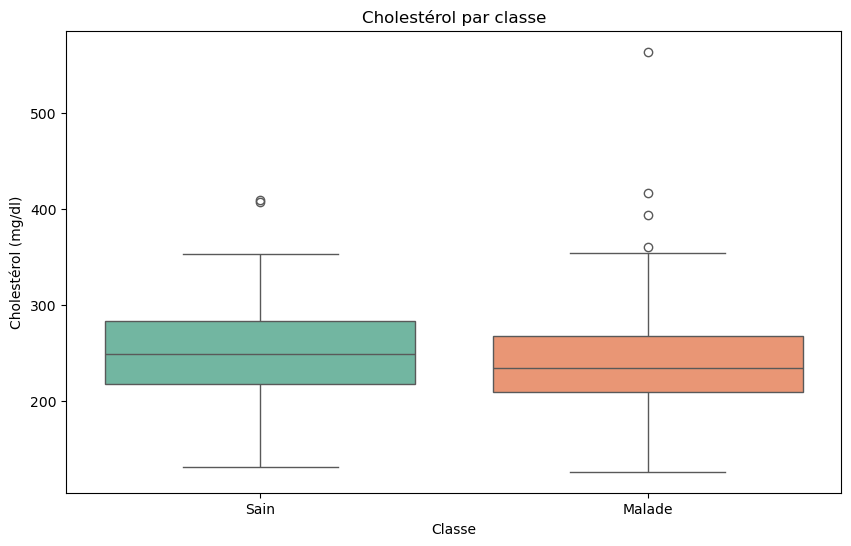

In [36]:
# ── Cholestérol par classe ──
plt.figure(figsize=(10, 6))
sns.boxplot(x='target', y='chol', data=df, palette='Set2')
plt.title('Cholestérol par classe')
plt.xlabel('Classe')
plt.ylabel('Cholestérol (mg/dl)')
plt.xticks([0, 1], ['Sain', 'Malade'])
plt.savefig('./images/EDA/cholesterol_boxplot.png', dpi=300, bbox_inches='tight')
plt.show()

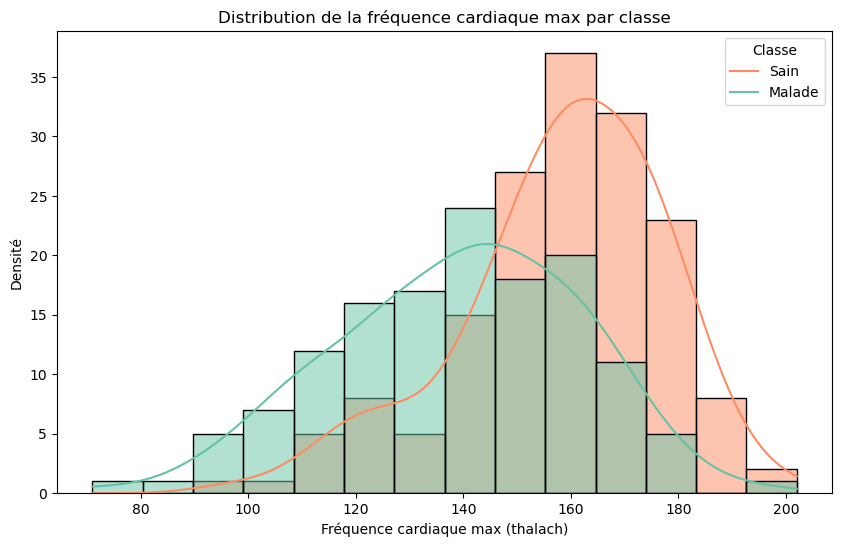

In [37]:
# ── Fréquence cardiaque max par classe ──
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='thalach', hue='target', kde=True, palette='Set2')
plt.title('Distribution de la fréquence cardiaque max par classe')
plt.xlabel('Fréquence cardiaque max (thalach)')
plt.ylabel('Densité')
plt.legend(title='Classe', labels=['Sain', 'Malade'])
plt.savefig('./images/EDA/thalach_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

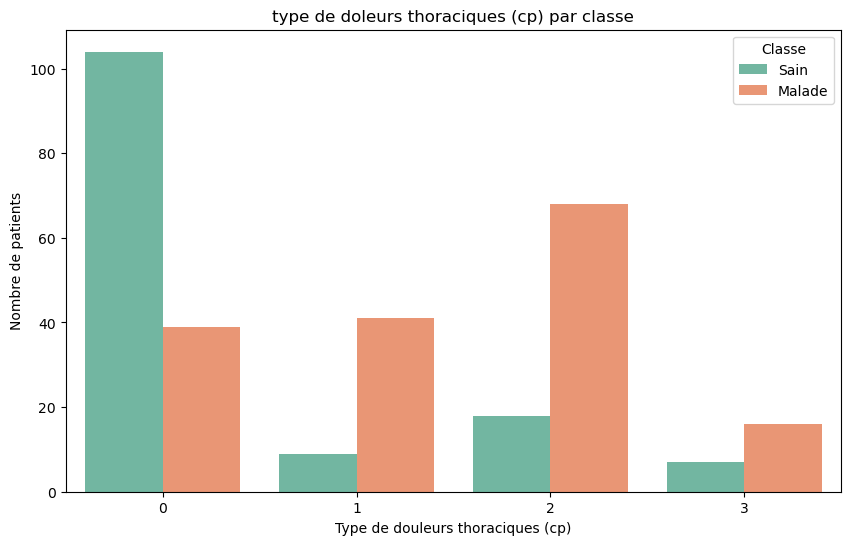

In [38]:
# ── Variables catégorielles vs cible ──
plt.figure(figsize=(10, 6))
plt.title('type de doleurs thoraciques (cp) par classe')
sns.countplot(x='cp', hue='target', data=df, palette='Set2')
plt.xlabel('Type de douleurs thoraciques (cp)')
plt.ylabel('Nombre de patients')
plt.legend(title='Classe', labels=['Sain', 'Malade'])
plt.savefig('./images/EDA/cp_target.png', dpi=300, bbox_inches='tight')
plt.show()

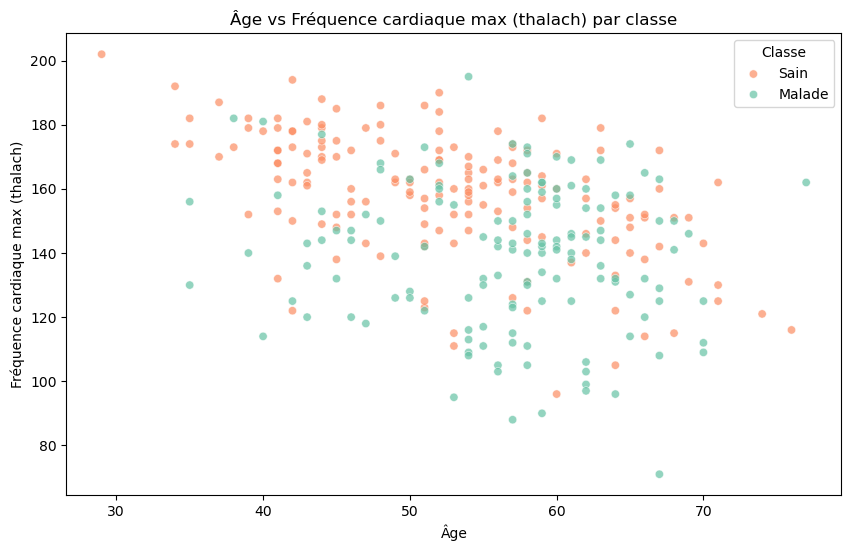

In [39]:
# ── Scatter : âge vs thalach coloré par cible ──
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='age', y='thalach', hue='target', palette='Set2', alpha=0.7)
plt.title('Âge vs Fréquence cardiaque max (thalach) par classe')
plt.xlabel('Âge')
plt.ylabel('Fréquence cardiaque max (thalach)')
plt.legend(title='Classe', labels=['Sain', 'Malade'])
plt.savefig('./images/EDA/age_thalach_scatter.png', dpi=300, bbox_inches='tight')
plt.show()

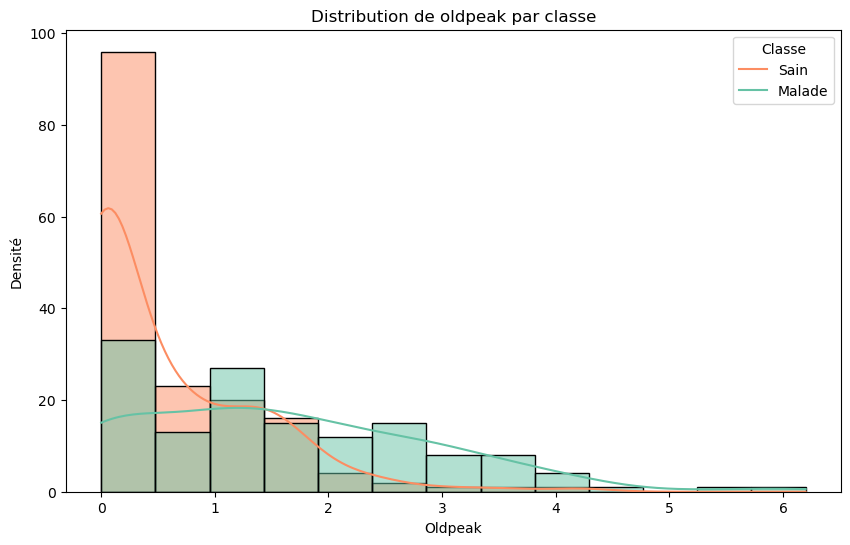

In [41]:
# ── Oldpeak par classe 
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='oldpeak', hue='target', kde=True, palette='Set2')
plt.title('Distribution de oldpeak par classe')
plt.xlabel('Oldpeak')
plt.ylabel('Densité')
plt.legend(title='Classe', labels=['Sain', 'Malade'])
plt.savefig('./images/EDA/oldpeak_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

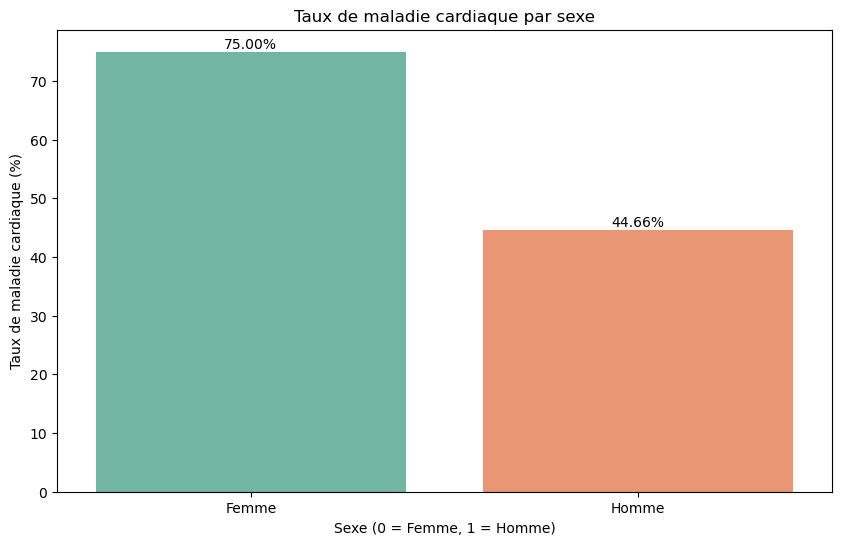

In [56]:
# ── Taux de maladie par sexe ──
sex_rate = df.groupby('sex')['target'].mean() * 100
plt.figure(figsize=(10, 6))
ax = sns.barplot(x=sex_rate.index, y=sex_rate.values, palette='Set2')
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f%%', label_type='edge', fontsize=10)
plt.title('Taux de maladie cardiaque par sexe')
plt.xlabel('Sexe (0 = Femme, 1 = Homme)')
plt.ylabel('Taux de maladie cardiaque (%)')
plt.xticks([0, 1], ['Femme', 'Homme'])
plt.savefig('./images/EDA/sex_rate.png', dpi=300, bbox_inches='tight')
plt.show()

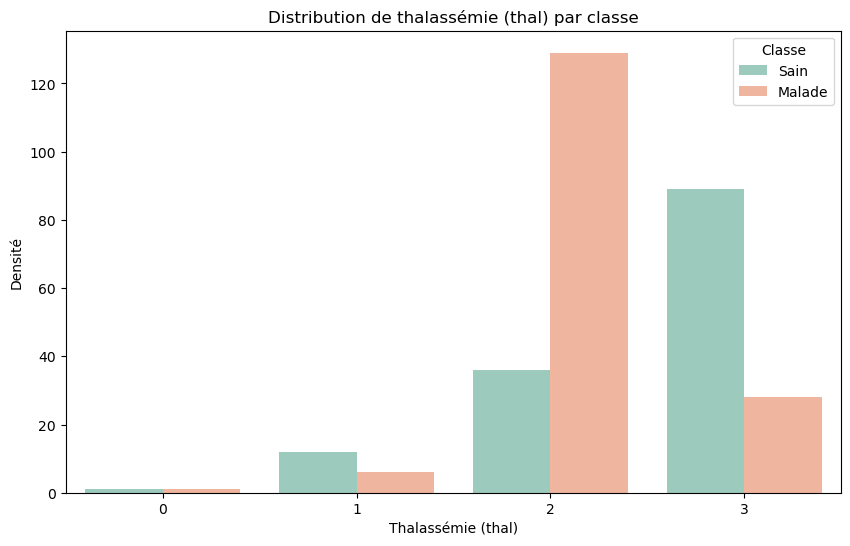

In [52]:
# thalassémie (thal) par classe
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='thal', hue='target', palette='Set2',alpha=0.7)
plt.title('Distribution de thalassémie (thal) par classe')
plt.xlabel('Thalassémie (thal)')
plt.ylabel('Densité')
plt.legend(title='Classe', labels=['Sain', 'Malade'])
plt.savefig('./images/EDA/thal_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

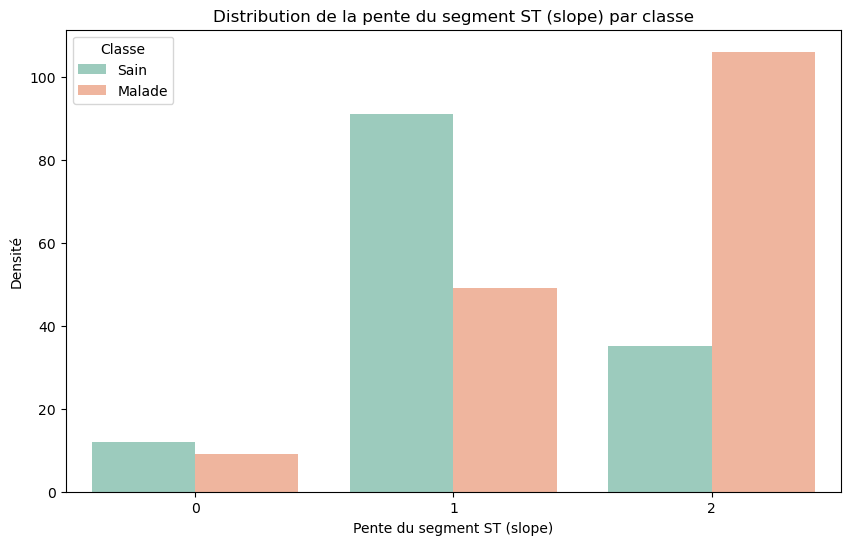

In [57]:
# pente du segment ST (slope) par classe
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='slope', hue='target', palette='Set2',alpha=0.7)
plt.title('Distribution de la pente du segment ST (slope) par classe')
plt.xlabel('Pente du segment ST (slope)')
plt.ylabel('Densité')
plt.legend(title='Classe', labels=['Sain', 'Malade'])
plt.savefig('./images/EDA/slope_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

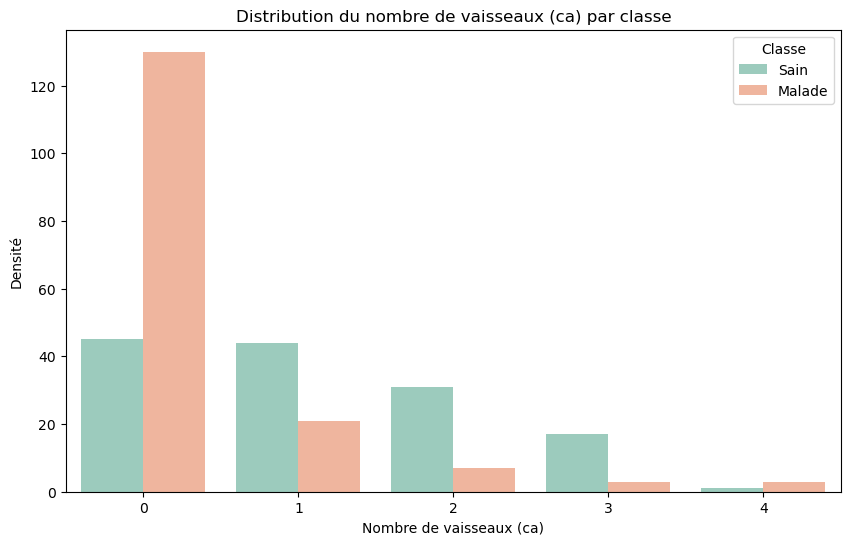

In [58]:
# vaissureaux (ca) par classe
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='ca', hue='target', palette='Set2',alpha=0.7)
plt.title('Distribution du nombre de vaisseaux (ca) par classe')
plt.xlabel('Nombre de vaisseaux (ca)')
plt.ylabel('Densité')
plt.legend(title='Classe', labels=['Sain', 'Malade'])
plt.savefig('./images/EDA/ca_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

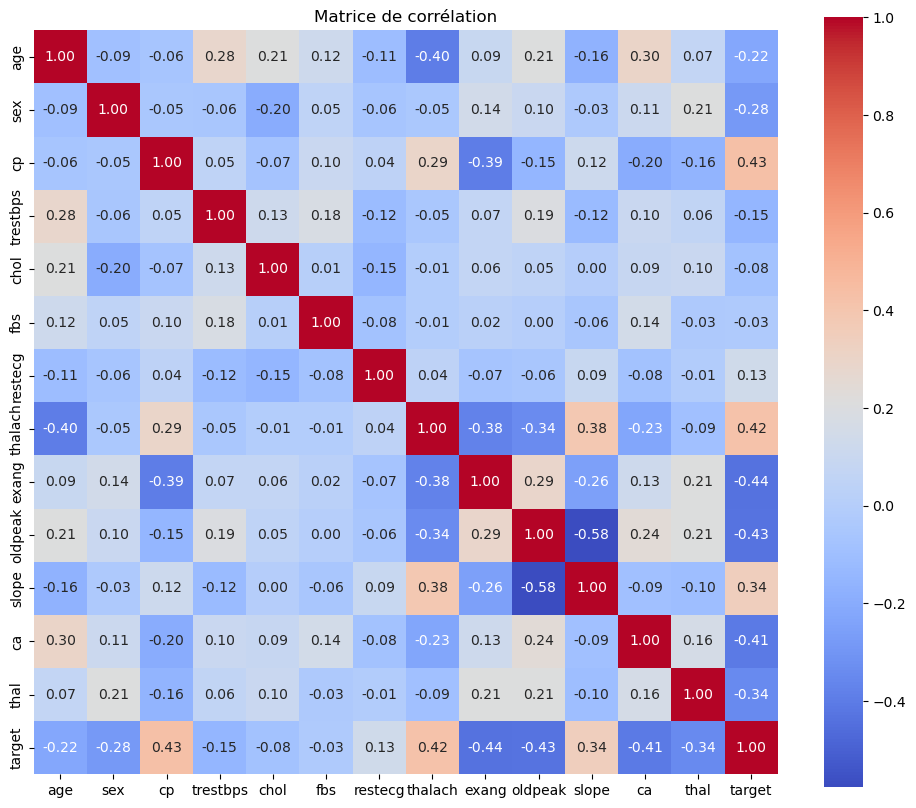

In [59]:
# Matrice de corrélation
plt.figure(figsize=(12, 10))
corr = df.corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', cbar=True, square=True)
plt.title('Matrice de corrélation')
plt.savefig('./images/EDA/correlation_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

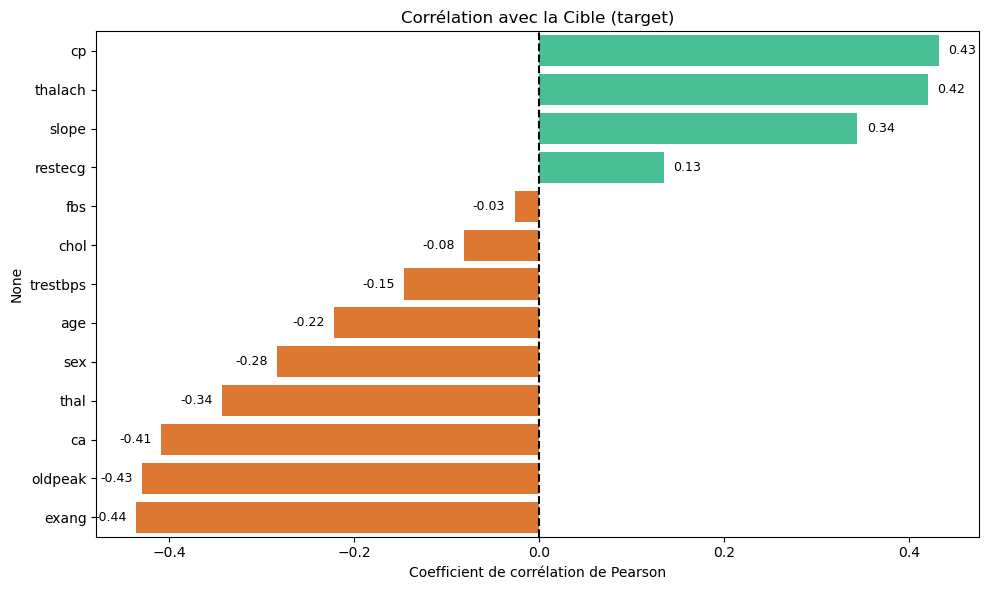

In [70]:
# corrélation avec la cible
corr_target = corr['target'].drop('target').sort_values(ascending=False)
colors_bar = ['#f97316' if v < 0 else '#34d399' for v in corr_target.values]

plt.figure(figsize=(10, 6))
ax = sns.barplot(x=corr_target.values, y=corr_target.index, palette=colors_bar)
plt.axvline(0, color='black', linestyle='--')
plt.title('Corrélation avec la Cible (target)')
plt.xlabel('Coefficient de corrélation de Pearson')

for i, val in enumerate(corr_target.values):
    ax.text(val + (0.01 if val >= 0 else -0.01), i,
            f'{val:.2f}', va='center', ha='left' if val >= 0 else 'right',
            fontsize=9)

plt.tight_layout()
plt.savefig('./images/EDA/target_correlation.png', dpi=300, bbox_inches='tight')
plt.show()

In [71]:
print("Variables les plus corrélées à la cible :")
for feat, val in corr_target.abs().sort_values(ascending=False).head(5).items():
    direction = "↑ Positif" if corr_target[feat] > 0 else "↓ Négatif"
    print(f"   {feat:12s} : r = {corr_target[feat]:+.3f}  ({direction})")


Variables les plus corrélées à la cible :
   exang        : r = -0.436  (↓ Négatif)
   cp           : r = +0.432  (↑ Positif)
   oldpeak      : r = -0.429  (↓ Négatif)
   thalach      : r = +0.420  (↑ Positif)
   ca           : r = -0.409  (↓ Négatif)
